[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tommy-Burns/easy-eo/blob/main/examples/01_fundamentals/05_stacking_bands.ipynb)

# Stacking bands

Satellite data usually arrives as one file per band. `stack` combines them into a single multi-band dataset you can address by name.

- **Data:** the four Sentinel-2 sample bands as separate files
- **Network:** only for the first download of the sample

**Stack is not mosaic.** Stacking layers *bands* on the same footprint; mosaicking joins *tiles* side by side in space (see [02_clip_and_mosaic](02_clip_and_mosaic.ipynb)). They are deliberately separate operations.

In [ ]:
# Running in Colab? Install Easy-EO. Does nothing anywhere else.
import sys

if "google.colab" in sys.modules:
    %pip install -q "easy-eo"


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

## One file per band

The sample ships the same four bands both ways: pre-stacked, and as separate single-band files. Here we use the separate ones.

In [2]:
from eeo import load_raster
from eeo.datasets import load_sample_dataset

sd = load_sample_dataset()

blue = load_raster(sd.sentinel2_blue)
green = load_raster(sd.sentinel2_green)
red = load_raster(sd.sentinel2_red)
nir = load_raster(sd.sentinel2_nir)

for name, ds in (("blue", blue), ("green", green), ("red", red), ("nir", nir)):
    print(f"{name:6s} {ds.get_shape()}  {ds.get_count()} band  {ds.get_metadata()['dtype']}  {ds.band_names}")

blue   (1024, 1024)  1 band  uint16  ['blue']
green  (1024, 1024)  1 band  uint16  ['green']
red    (1024, 1024)  1 band  uint16  ['red']
nir    (1024, 1024)  1 band  uint16  ['nir']


## Stacking

Call `stack` on the band that should come first and hand it the rest, in order. Band order is entirely up to you - but it is what every later `bands=` argument refers to, so decide it deliberately.

In [3]:
scene = blue.stack([green, red, nir], names=["blue", "green", "red", "nir"])

scene.describe()

EEORasterDataset
  source      : <in-memory>
  driver      : GTiff
  bands       : 4
  band names  : 1: blue, 2: green, 3: red, 4: nir
  size        : 1024 × 1024  (height × width)
  dtype       : uint16
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5340230, 387960, 5350470  (minx, miny, maxx, maxy)
  nodata      : 0.0
  timestamp   : none
  attrs       : none


Without `names=`, the stack keeps whatever names the inputs carried. Supplying them explicitly is worth the few extra characters - every subsequent operation becomes readable.

In [4]:
unnamed = blue.stack([green, red, nir])
print("inherited :", unnamed.band_names)
print("explicit  :", scene.band_names)
unnamed.close()

inherited : ['blue', 'green', 'red', 'nir']
explicit  : ['blue', 'green', 'red', 'nir']


## Using it

The stacked scene behaves exactly like the pre-stacked sample file - bands by name, composites, indices.

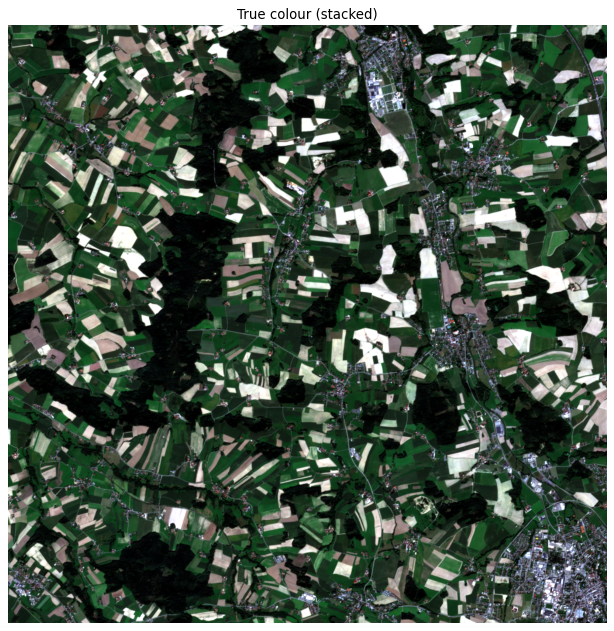

In [5]:
scene.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="True colour (stacked)")

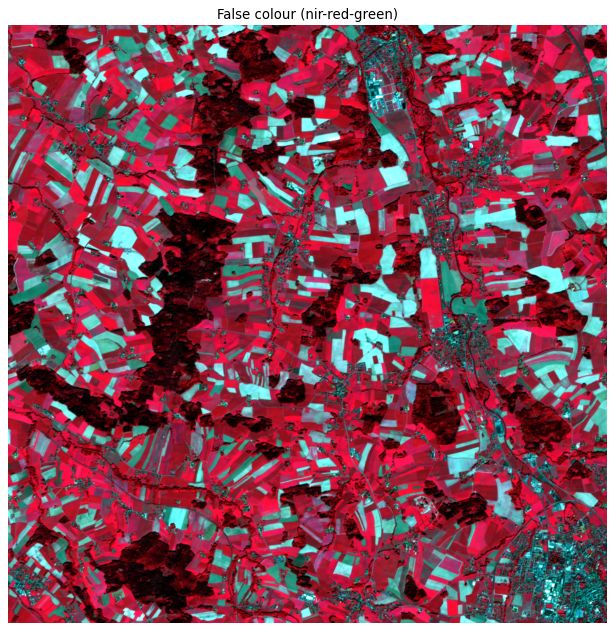

In [6]:
scene.plot_composite(["nir", "red", "green"], pmin=2, pmax=98, title="False colour (nir-red-green)")

In false colour, healthy vegetation is red because it reflects strongly in the near-infrared - the same signal NDVI measures numerically.

In [7]:
import numpy as np

ndvi = scene.ndvi(red="red", nir="nir")
print("NDVI mean:", f"{float(np.nanmean(ndvi.get_band(1))):.4f}")

NDVI mean: 0.4434


### It matches the pre-stacked file

Same data, assembled two ways.

In [8]:
prestacked = load_raster(sd.sentinel2_stacked)

print("band names match:", scene.band_names == prestacked.band_names)
print("shapes match    :", scene.get_shape() == prestacked.get_shape())
print("values match    :", np.array_equal(scene.to_array(), prestacked.to_array()))

band names match: True
shapes match    : True
values match    : True


## Mismatched grids

Bands do not always share a grid - Sentinel-2's SWIR bands are 20 m while the visible and near-infrared bands are 10 m. Put them on a common grid before stacking; `resample` and `reproject_raster` are covered in [03_reproject_and_resample](03_reproject_and_resample.ipynb).

In [9]:
coarse = nir.resample(scale_factor=0.5, resampling_method="average")
print("nir    :", nir.get_shape())
print("coarse :", coarse.get_shape(), "<- a 20 m band, in effect")

regridded = coarse.resample(size=(nir.get_width(), nir.get_height()), resampling_method="bilinear")
print("regridded:", regridded.get_shape())

five_band = scene.stack(regridded, names=["blue", "green", "red", "nir", "nir_20m"])
print("stacked  :", five_band.get_count(), "bands", five_band.band_names)

nir    : (1024, 1024)
coarse : (512, 512) <- a 20 m band, in effect
regridded: (1024, 1024)
stacked  : 5 bands ['blue', 'green', 'red', 'nir', 'nir_20m']


## Saving

`save_raster` writes the stack as a multi-band GeoTIFF, and the band names go into the file's GDAL descriptions - so they are still there next time you open it.

In [10]:
import tempfile
from pathlib import Path

out_dir = Path(tempfile.mkdtemp())
path = out_dir / "sentinel2_stack.tif"
scene.save_raster(str(path))

reopened = load_raster(path)
print("band names survived the round trip:", reopened.band_names)
reopened.describe()

band names survived the round trip: ['blue', 'green', 'red', 'nir']
EEORasterDataset
  source      : /tmp/tmp22mhli2w/sentinel2_stack.tif
  driver      : GTiff
  bands       : 4
  band names  : 1: blue, 2: green, 3: red, 4: nir
  size        : 1024 × 1024  (height × width)
  dtype       : uint16
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5340230, 387960, 5350470  (minx, miny, maxx, maxy)
  nodata      : 0.0
  timestamp   : none
  attrs       : none


In [11]:
for ds in (blue, green, red, nir, scene, ndvi, prestacked, coarse, regridded, five_band, reopened):
    ds.close()
print("closed")

closed


## Next

- **[06_statistics_and_extraction](06_statistics_and_extraction.ipynb)** - pull numbers out of a raster